In [168]:
# !pip install kagglehub

In [169]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder , OrdinalEncoder , LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA

sns.set()
parisrohan_credit_score_classification_path = kagglehub.dataset_download('parisrohan/credit-score-classification')

print('Data source import complete.')


Data source import complete.


# Analysing and Exploration

In [170]:
path = kagglehub.dataset_download("parisrohan/credit-score-classification")

train = pd.read_csv(f"{path}/train.csv")
test = pd.read_csv(f"{path}/test.csv")

/var/folders/4k/q5xn50lx7hb2slknt2ygk7hc0000gn/T/ipykernel_44478/2046096389.py:3: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv(f"{path}/train.csv")


In [171]:
# Adiciona a coluna 'origem' a cada DataFrame
train['Origem'] = 'train'
test['Origem'] = 'test'
 
# Concatena os dois DataFrames
df = pd.concat([train, test], ignore_index=True)

In [172]:
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Origem
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good,train
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good,train
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good,train
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good,train
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good,train


In [173]:
df.shape

(150000, 29)

In [174]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 29 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        150000 non-null  object 
 1   Customer_ID               150000 non-null  object 
 2   Month                     150000 non-null  object 
 3   Name                      135000 non-null  object 
 4   Age                       150000 non-null  object 
 5   SSN                       150000 non-null  object 
 6   Occupation                150000 non-null  object 
 7   Annual_Income             150000 non-null  object 
 8   Monthly_Inhand_Salary     127500 non-null  float64
 9   Num_Bank_Accounts         150000 non-null  int64  
 10  Num_Credit_Card           150000 non-null  int64  
 11  Interest_Rate             150000 non-null  int64  
 12  Num_of_Loan               150000 non-null  object 
 13  Type_of_Loan              132888 non-null  o

In [175]:
df.drop(columns=['ID','Customer_ID'],inplace=True)

In [176]:
null_df = df.isna().sum()

<Axes: >

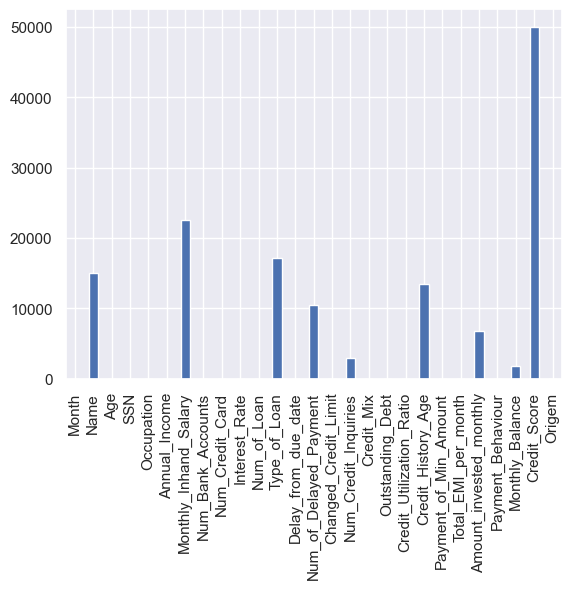

In [177]:
null_df.plot(kind='bar')

In [178]:
df.duplicated().sum()

0

In [179]:
df.describe()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,127500.000000,150000.000000,150000.000000,150000.000000,150000.000000,147000.000000,150000.000000,150000.000000
mean,4190.115139,17.006940,22.623447,71.234907,21.063400,28.529014,32.283309,1432.513579
std,3180.489657,117.069476,129.143006,461.537193,14.860154,194.456058,5.113315,8403.759977
min,303.645417,-1.000000,0.000000,1.000000,-5.000000,0.000000,20.000000,0.000000
25%,1625.265833,3.000000,4.000000,8.000000,10.000000,3.000000,28.054731,30.947775
50%,3091.000000,6.000000,5.000000,13.000000,18.000000,6.000000,32.297058,71.280006
75%,5948.454596,7.000000,7.000000,20.000000,28.000000,9.000000,36.487954,166.279555
max,15204.633333,1798.000000,1499.000000,5799.000000,67.000000,2597.000000,50.000000,82398.000000


* Correcting the dtypes

In [180]:
columns_to_convert = [
    "Annual_Income",
    "Changed_Credit_Limit",
    "Outstanding_Debt",
    "Amount_invested_monthly",
    "Monthly_Balance"
]

# Replace non-numeric characters and empty strings with NaN, then convert to float
df[columns_to_convert] = (
    df[columns_to_convert]
    .replace('[^\d.]', '', regex=True)  # Remove unwanted characters
    .replace('', np.nan)  # Replace empty strings with NaN
    .astype(float)  # Convert to float
)


<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:12: SyntaxWarning: invalid escape sequence '\d'
/var/folders/4k/q5xn50lx7hb2slknt2ygk7hc0000gn/T/ipykernel_44478/616979661.py:12: SyntaxWarning: invalid escape sequence '\d'
  .replace('[^\d.]', '', regex=True)  # Remove unwanted characters


In [181]:
columns_to_convert = ["Age", "Num_of_Loan", "Num_of_Delayed_Payment"]

# Convert to numeric, forcing errors to NaN if conversion fails
df[columns_to_convert] = df[columns_to_convert].apply(pd.to_numeric, errors='coerce')

In [182]:
num = df.select_dtypes(include=['number','float'])
cat = df.select_dtypes(include=['object'])

# Visualising Data

In [183]:
# # Select numeric columns only

# # Set figure size for better readability
# plt.figure(figsize=(16, 10))

# # Iterate through each numeric column and create boxplot
# for i, column in enumerate(num.columns):
#     plt.subplot(len(num.columns)//2 + 1, 2, i + 1)
#     sns.boxplot(x=train[column])
#     plt.title(f'Boxplot of {column}')

# # Adjust layout for better spacing
# plt.tight_layout()
# plt.show()

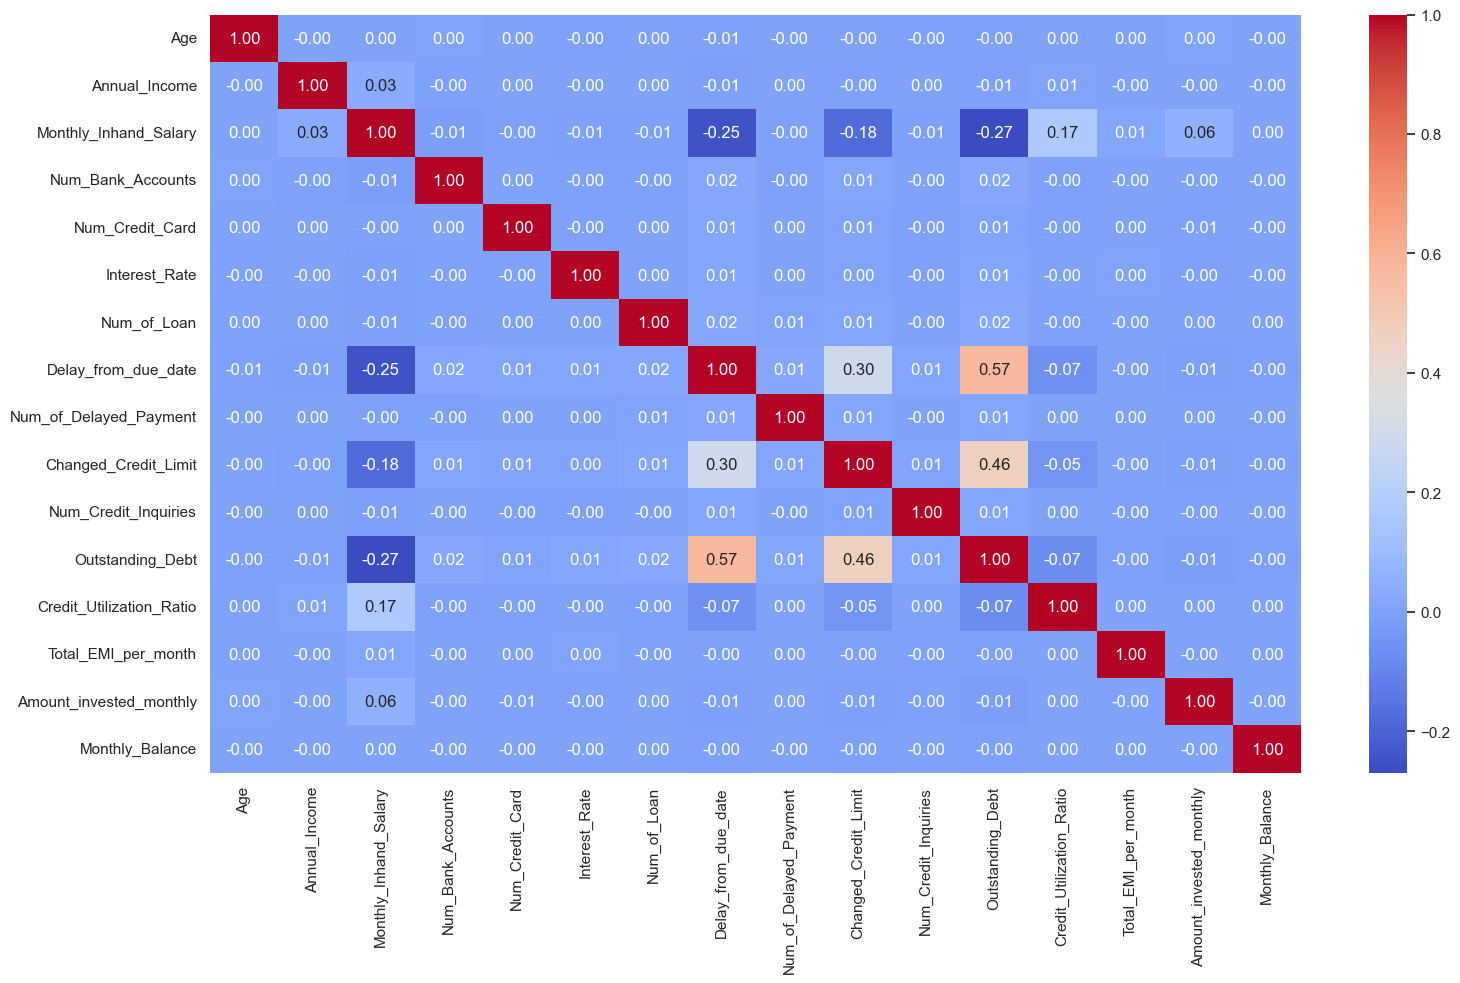

In [184]:
plt.figure(figsize=(16, 10))
sns.heatmap(num.corr(), annot=True, cmap='coolwarm', fmt='.2f')

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

In [185]:
num.corr()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
Age,1.000000,-0.001664,0.002585,0.004852,0.000566,-0.003912,0.000887,-0.005308,-0.001591,-0.001457,-0.003752,-0.002482,0.001524,0.000793,0.003782,-0.001124
Annual_Income,-0.001664,1.000000,0.030485,-0.003012,0.000594,-0.001375,0.002869,-0.009440,0.000730,-0.001902,0.002149,-0.005341,0.006496,-0.000836,-0.001485,-0.000829
Monthly_Inhand_Salary,0.002585,0.030485,1.000000,-0.012179,-0.004418,-0.009275,-0.010135,-0.249600,-0.003081,-0.175995,-0.007838,-0.269610,0.170601,0.011099,0.060134,0.001866
Num_Bank_Accounts,0.004852,-0.003012,-0.012179,1.000000,0.001534,-0.001962,-0.001931,0.016774,-0.003443,0.008821,-0.000176,0.015162,-0.002591,-0.000095,-0.000133,-0.001106
Num_Credit_Card,0.000566,0.000594,-0.004418,0.001534,1.000000,-0.002670,0.000154,0.009117,0.002785,0.005684,-0.002204,0.006249,-0.001932,0.002231,-0.005827,-0.001351
Interest_Rate,-0.003912,-0.001375,-0.009275,-0.001962,-0.002670,1.000000,0.000438,0.011016,0.001740,0.003637,-0.002887,0.009496,-0.001023,0.003421,-0.002073,-0.001309
Num_of_Loan,0.000887,0.002869,-0.010135,-0.001931,0.000154,0.000438,1.000000,0.015171,0.005277,0.012863,-0.000064,0.020989,-0.003901,-0.001110,0.000328,0.000022
Delay_from_due_date,-0.005308,-0.009440,-0.249600,0.016774,0.009117,0.011016,0.015171,1.000000,0.014584,0.297352,0.008334,0.571650,-0.065657,-0.001490,-0.011171,-0.003227
Num_of_Delayed_Payment,-0.001591,0.000730,-0.003081,-0.003443,0.002785,0.001740,0.005277,0.014584,1.000000,0.009957,-0.000835,0.011526,0.000418,0.000031,0.000177,-0.000983
Changed_Credit_Limit,-0.001457,-0.001902,-0.175995,0.008821,0.005684,0.003637,0.012863,0.297352,0.009957,1.000000,0.007338,0.463948,-0.048836,-0.001371,-0.010991,-0.002333


In [186]:
cat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   Month                  150000 non-null  object
 1   Name                   135000 non-null  object
 2   SSN                    150000 non-null  object
 3   Occupation             150000 non-null  object
 4   Type_of_Loan           132888 non-null  object
 5   Credit_Mix             150000 non-null  object
 6   Credit_History_Age     136500 non-null  object
 7   Payment_of_Min_Amount  150000 non-null  object
 8   Payment_Behaviour      150000 non-null  object
 9   Credit_Score           100000 non-null  object
 10  Origem                 150000 non-null  object
dtypes: object(11)
memory usage: 12.6+ MB


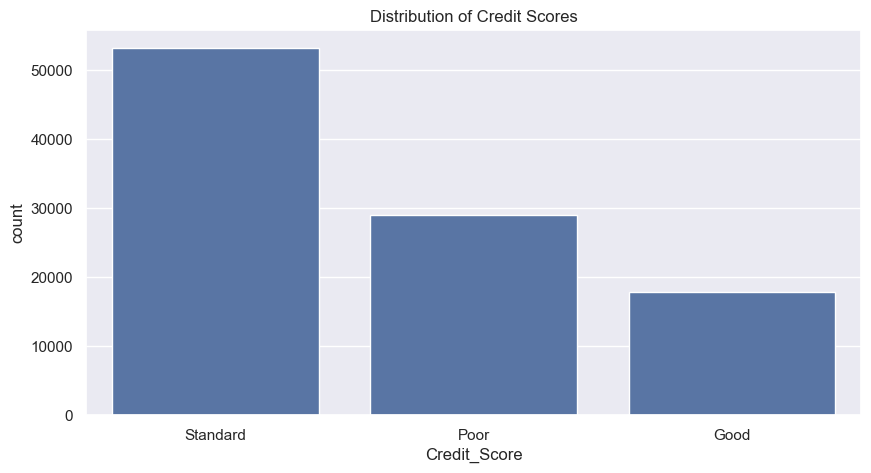

In [187]:
plt.figure(figsize=(10, 5))
sns.countplot(x=cat['Credit_Score'], order=cat['Credit_Score'].value_counts().index)
plt.title("Distribution of Credit Scores")
plt.show()

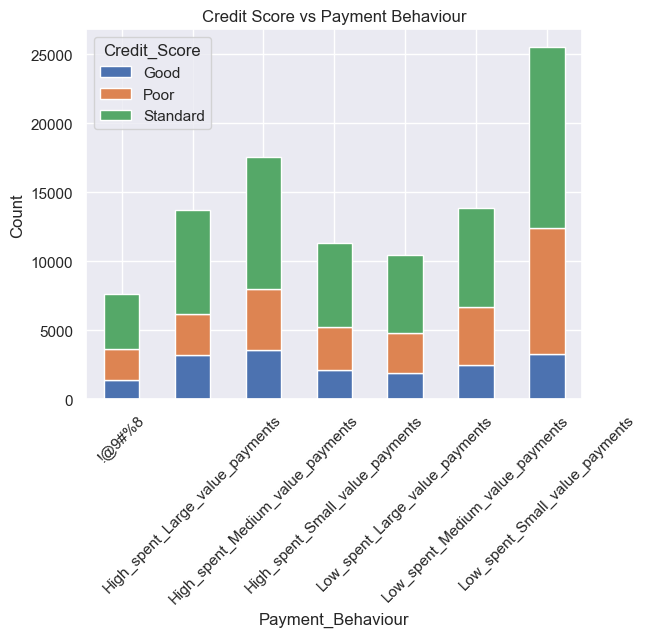

In [188]:
pd.crosstab(cat['Payment_Behaviour'], cat['Credit_Score']).plot(kind='bar', stacked=True)
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.title("Credit Score vs Payment Behaviour")
plt.show()


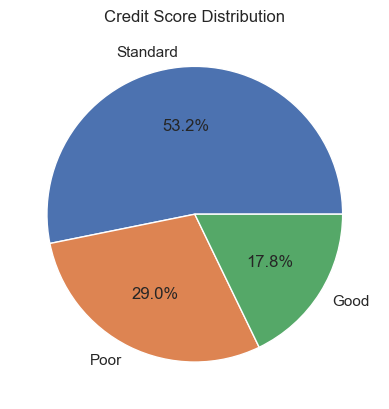

In [189]:
cat['Credit_Score'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.title("Credit Score Distribution")
plt.show()


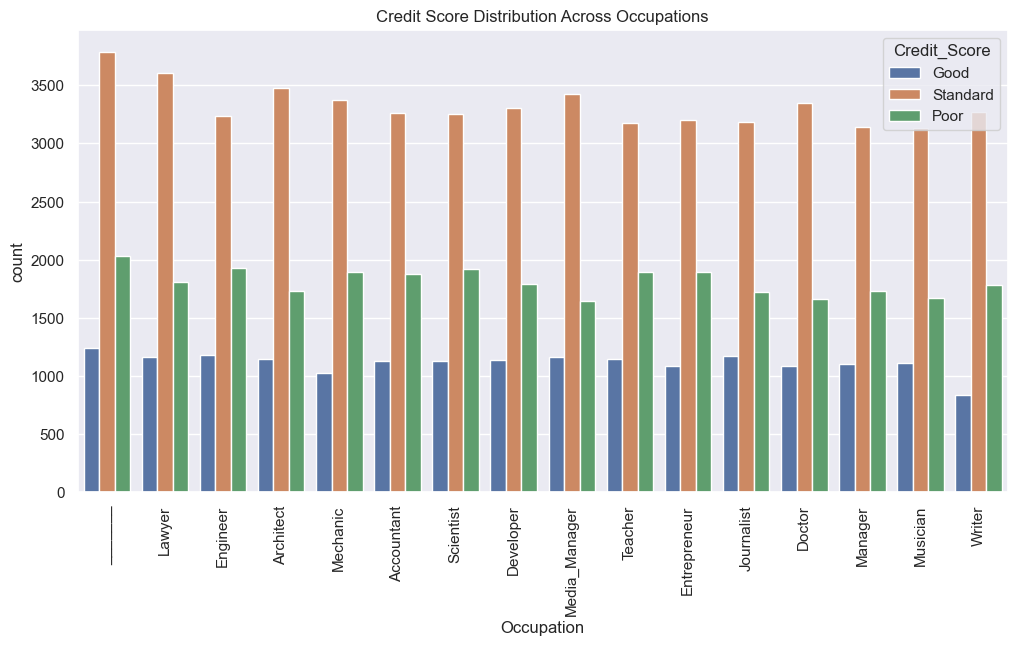

In [190]:
plt.figure(figsize=(12, 6))
sns.countplot(data=cat, x='Occupation', hue='Credit_Score', order=cat['Occupation'].value_counts().index)
plt.xticks(rotation=90)
plt.title("Credit Score Distribution Across Occupations")
plt.show()


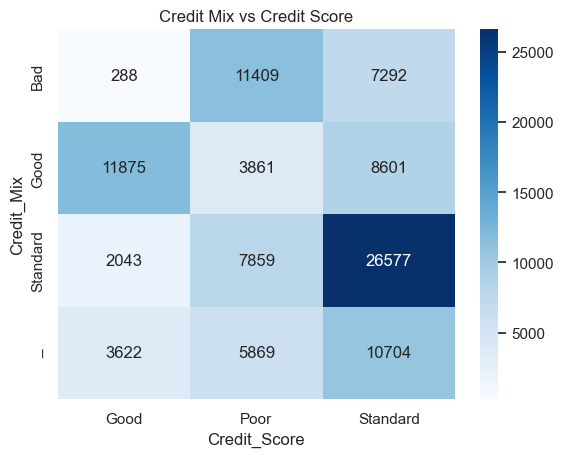

In [191]:
cross_tab = pd.crosstab(cat['Credit_Mix'], cat['Credit_Score'])
sns.heatmap(cross_tab, annot=True, cmap='Blues', fmt='d')
plt.title("Credit Mix vs Credit Score")
plt.show()


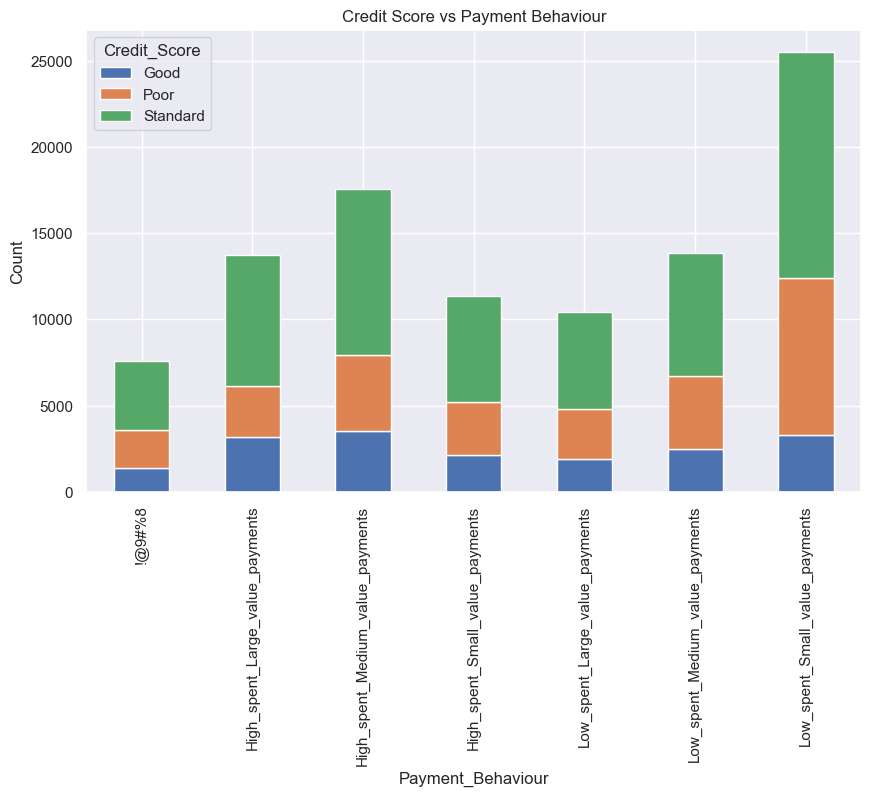

In [192]:
pd.crosstab(cat['Payment_Behaviour'], cat['Credit_Score']).plot(kind='bar', stacked=True, figsize=(10, 6))
plt.xticks(rotation=90)
plt.title("Credit Score vs Payment Behaviour")
plt.ylabel("Count")
plt.show()


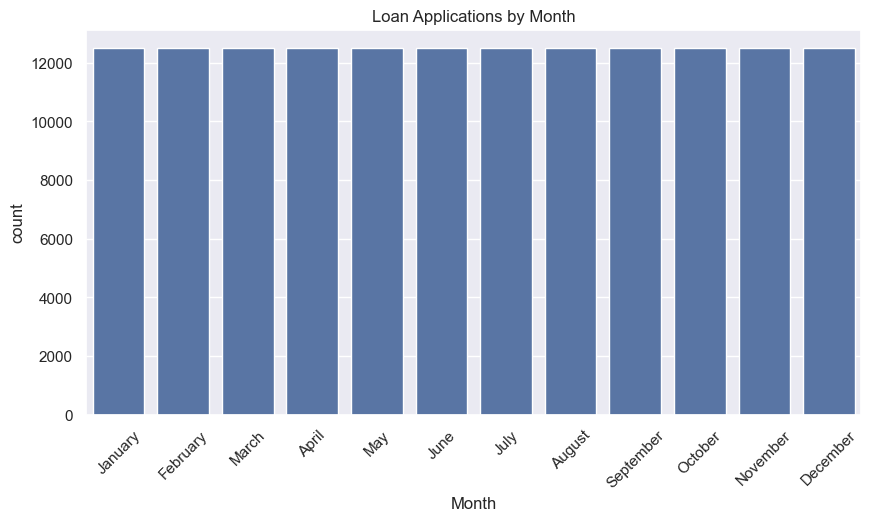

In [193]:
plt.figure(figsize=(10, 5))
sns.countplot(x=cat['Month'], order=cat['Month'].value_counts().index)
plt.title("Loan Applications by Month")
plt.xticks(rotation=45)
plt.show()


<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/var/folders/4k/q5xn50lx7hb2slknt2ygk7hc0000gn/T/ipykernel_44478/1855912459.py:1: SyntaxWarning: invalid escape sequence '\d'
  cat['Credit_History_Age'] = cat['Credit_History_Age'].str.extract('(\d+)').astype(float)  # Extract numeric part


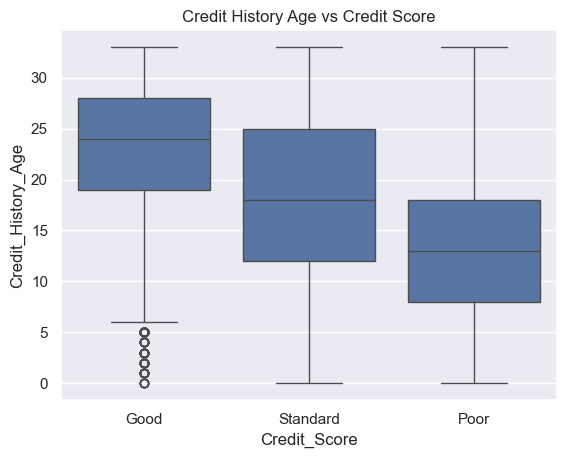

In [194]:
cat['Credit_History_Age'] = cat['Credit_History_Age'].str.extract('(\d+)').astype(float)  # Extract numeric part
sns.boxplot(x='Credit_Score', y='Credit_History_Age', data=cat)
plt.title("Credit History Age vs Credit Score")
plt.show()


# Capping the Outliers

In [195]:
capped = df.copy()

for i in num:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1
    upper_limit = Q3 + 1.5 * IQR
    lower_limit = Q1 - 1.5 * IQR

    # Ensure logical lower bounds
    if i in ['Age']:
        lower_limit = max(lower_limit, 18)  # Age should be at least 18

    elif i in ['Num_Bank_Accounts', 'Num_Credit_Card', 'Num_of_Loan', 'Num_of_Delayed_Payment', 'Num_Credit_Inquiries']:
        lower_limit = max(lower_limit, 0)  # These should not be negative

    elif i in ['Outstanding_Debt', 'Amount_invested_monthly', 'Total_EMI_per_month', 'Monthly_Balance']:
        lower_limit = max(lower_limit, 0)  # These should be non-negative

    # Cap the values
    capped[i] = np.where(
        capped[i] > upper_limit, upper_limit,
        np.where(capped[i] < lower_limit, lower_limit, capped[i])
    )


In [196]:
capped

,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,...,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Origem
0,January,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,1824.843333,3.0,4.0,3.0,...,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.415295,High_spent_Small_value_payments,312.494089,Good,train
1,February,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,NaN,3.0,4.0,3.0,...,809.98,31.944960,NaN,No,49.574949,118.280222,Low_spent_Large_value_payments,284.629162,Good,train
2,March,Aaron Maashoh,18.0,821-00-0265,Scientist,19114.12,NaN,3.0,4.0,3.0,...,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521,Low_spent_Medium_value_payments,331.209863,Good,train
3,April,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,NaN,3.0,4.0,3.0,...,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.458074,Low_spent_Small_value_payments,223.451310,Good,train
4,May,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,1824.843333,3.0,4.0,3.0,...,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153,High_spent_Medium_value_payments,341.489231,Good,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,December,Sarah McBridec,69.0,031-35-0942,Architect,20002.88,1929.906667,10.0,8.0,29.0,...,3571.70,34.780553,NaN,Yes,60.964772,146.486325,Low_spent_Small_value_payments,275.539570,NaN,test
149996,September,Nicks,25.0,078-73-5990,Mechanic,39628.99,NaN,4.0,6.0,7.0,...,502.38,27.758522,31 Years and 11 Months,NM,35.104023,181.442999,Low_spent_Small_value_payments,409.394562,NaN,test
149997,October,Nicks,25.0,078-73-5990,Mechanic,39628.99,3359.415833,4.0,6.0,7.0,...,502.38,36.858542,32 Years and 0 Months,No,35.104023,553.476338,Low_spent_Large_value_payments,349.726332,NaN,test
149998,November,Nicks,25.0,078-73-5990,Mechanic,39628.99,NaN,4.0,6.0,7.0,...,502.38,39.139840,32 Years and 1 Months,No,35.104023,97.598580,High_spent_Small_value_payments,463.238981,NaN,test


In [197]:
capped.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,142584.000000,150000.000000,127500.000000,150000.000000,150000.000000,150000.000000,142779.000000,150000.000000,135329.000000,146850.000000,147000.000000,150000.000000,150000.000000,150000.000000,143250.000000,148238.000000
mean,34.137905,51254.508006,4162.832418,5.467027,5.670333,15.000953,3.425644,20.891827,13.481700,10.453042,6.482034,1399.859920,32.283297,111.785811,197.414901,388.626150
std,11.584581,38688.168913,3101.049353,2.717982,2.232387,9.255950,2.546495,14.428794,6.465605,6.633687,4.204429,1086.191893,5.113275,108.626589,164.883254,175.379141
min,18.000000,7005.930000,303.645417,0.000000,0.000000,1.000000,0.000000,-5.000000,0.000000,0.000000,0.000000,0.230000,20.000000,0.000000,0.000000,0.007760
25%,24.000000,19455.490000,1625.265833,3.000000,4.000000,8.000000,1.000000,10.000000,9.000000,5.350000,3.000000,566.072500,28.054731,30.947775,74.533842,270.247057
50%,33.000000,37578.610000,3091.000000,6.000000,5.000000,13.000000,3.000000,18.000000,14.000000,9.410000,6.000000,1166.155000,32.297058,71.280006,135.791445,336.823681
75%,42.000000,72796.905000,5948.454596,7.000000,7.000000,20.000000,5.000000,28.000000,18.000000,14.840000,9.000000,1945.962500,36.487954,166.279555,266.110841,470.516286
max,69.000000,152809.027500,12433.237740,13.000000,11.500000,38.000000,11.000000,55.000000,31.500000,29.075000,18.000000,4015.797500,49.137788,369.277226,553.476338,770.920129


# Data Cleaning and Imputation

In [198]:
capped.drop(columns=['Name','SSN'],inplace=True)


## Imputation 1 - Random Imputation ( for categorical columns only)

In [199]:
knn = KNNImputer(n_neighbors=20)

In [200]:
def random_impute(series):
    non_na_values = series.dropna().values  # Get existing categories
    return series.apply(lambda x: np.random.choice(non_na_values) if pd.isna(x) else x)

In [201]:
capped.select_dtypes(include='object').isna().sum()

Month                        0
Occupation                   0
Type_of_Loan             17112
Credit_Mix                   0
Credit_History_Age       13500
Payment_of_Min_Amount        0
Payment_Behaviour            0
Credit_Score             50000
Origem                       0
dtype: int64

In [202]:
capped['Type_of_Loan'] = random_impute(capped['Type_of_Loan'])

In [203]:
capped['Credit_History_Age'] = random_impute(capped['Credit_History_Age'])

In [204]:
capped.select_dtypes(include='object').isna().sum()

Month                        0
Occupation                   0
Type_of_Loan                 0
Credit_Mix                   0
Credit_History_Age           0
Payment_of_Min_Amount        0
Payment_Behaviour            0
Credit_Score             50000
Origem                       0
dtype: int64

In [205]:
capped.isna().sum()

Month                           0
Age                          7416
Occupation                      0
Annual_Income                   0
Monthly_Inhand_Salary       22500
Num_Bank_Accounts               0
Num_Credit_Card                 0
Interest_Rate                   0
Num_of_Loan                  7221
Type_of_Loan                    0
Delay_from_due_date             0
Num_of_Delayed_Payment      14671
Changed_Credit_Limit         3150
Num_Credit_Inquiries         3000
Credit_Mix                      0
Outstanding_Debt                0
Credit_Utilization_Ratio        0
Credit_History_Age              0
Payment_of_Min_Amount           0
Total_EMI_per_month             0
Amount_invested_monthly      6750
Payment_Behaviour               0
Monthly_Balance              1762
Credit_Score                50000
Origem                          0
dtype: int64

In [206]:
capped.select_dtypes(include='object').isna().sum()

Month                        0
Occupation                   0
Type_of_Loan                 0
Credit_Mix                   0
Credit_History_Age           0
Payment_of_Min_Amount        0
Payment_Behaviour            0
Credit_Score             50000
Origem                       0
dtype: int64

In [207]:
capped['Type_of_Loan'] = random_impute(capped['Type_of_Loan'])

In [208]:
capped['Credit_History_Age'] = random_impute(capped['Credit_History_Age'])

In [209]:
imputer = ColumnTransformer(transformers=[
    ('knn',knn,['Age','Monthly_Inhand_Salary','Num_of_Loan','Num_of_Delayed_Payment','Changed_Credit_Limit','Changed_Credit_Limit','Num_Credit_Inquiries','Amount_invested_monthly','Monthly_Balance'])
],remainder='passthrough')

In [210]:
# y = capped['Credit_Score']
y = capped[capped['Origem'] == 'train']['Credit_Score']
capped.drop(columns='Credit_Score',inplace=True)

In [211]:
capped

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Origem
0,January,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.415295,High_spent_Small_value_payments,312.494089,train
1,February,23.0,Scientist,19114.12,NaN,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,Good,809.98,31.944960,13 Years and 0 Months,No,49.574949,118.280222,Low_spent_Large_value_payments,284.629162,train
2,March,18.0,Scientist,19114.12,NaN,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521,Low_spent_Medium_value_payments,331.209863,train
3,April,23.0,Scientist,19114.12,NaN,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.458074,Low_spent_Small_value_payments,223.451310,train
4,May,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153,High_spent_Medium_value_payments,341.489231,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,December,69.0,Architect,20002.88,1929.906667,10.0,8.0,29.0,5.0,"Personal Loan, Auto Loan, Mortgage Loan, Stude...",...,_,3571.70,34.780553,2 Years and 11 Months,Yes,60.964772,146.486325,Low_spent_Small_value_payments,275.539570,test
149996,September,25.0,Mechanic,39628.99,NaN,4.0,6.0,7.0,NaN,"Auto Loan, and Student Loan",...,Good,502.38,27.758522,31 Years and 11 Months,NM,35.104023,181.442999,Low_spent_Small_value_payments,409.394562,test
149997,October,25.0,Mechanic,39628.99,3359.415833,4.0,6.0,7.0,2.0,"Auto Loan, and Student Loan",...,Good,502.38,36.858542,32 Years and 0 Months,No,35.104023,553.476338,Low_spent_Large_value_payments,349.726332,test
149998,November,25.0,Mechanic,39628.99,NaN,4.0,6.0,7.0,NaN,"Auto Loan, and Student Loan",...,Good,502.38,39.139840,32 Years and 1 Months,No,35.104023,97.598580,High_spent_Small_value_payments,463.238981,test


In [212]:
df_train = capped[capped['Origem'] == 'train']
df_test = capped[capped['Origem'] == 'test']

df_train.drop(columns='Origem',inplace=True)
df_test.drop(columns='Origem',inplace=True)

/var/folders/4k/q5xn50lx7hb2slknt2ygk7hc0000gn/T/ipykernel_44478/3249012413.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train.drop(columns='Origem',inplace=True)
/var/folders/4k/q5xn50lx7hb2slknt2ygk7hc0000gn/T/ipykernel_44478/3249012413.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test.drop(columns='Origem',inplace=True)


In [213]:
train_imputed = imputer.fit_transform(df_train)

In [214]:
test_imputed = imputer.transform(df_test)

In [215]:
train_imputed = pd.DataFrame(train_imputed,columns=imputer.get_feature_names_out())
test_imputed = pd.DataFrame(test_imputed,columns=imputer.get_feature_names_out())

## Feature Engineering

In [216]:
print("Zero values in Annual_Income:", (train_imputed["remainder__Annual_Income"] == 0).sum())
print("Zero values in Num_of_Loan:", (train_imputed["knn__Num_of_Loan"] == 0).sum())
print("Zero values in Num_Credit_Card:", (train_imputed["remainder__Num_Credit_Card"] == 0).sum())
print("Zero values in Total_EMI_per_month:", (train_imputed["remainder__Total_EMI_per_month"] == 0).sum())


Zero values in Annual_Income: 0
Zero values in Num_of_Loan: 14256
Zero values in Num_Credit_Card: 13
Zero values in Total_EMI_per_month: 10613


In [217]:
print("Zero values in Annual_Income:", (test_imputed["remainder__Annual_Income"] == 0).sum())
print("Zero values in Num_of_Loan:", (test_imputed["knn__Num_of_Loan"] == 0).sum())
print("Zero values in Num_Credit_Card:", (test_imputed["remainder__Num_Credit_Card"] == 0).sum())
print("Zero values in Total_EMI_per_month:", (test_imputed["remainder__Total_EMI_per_month"] == 0).sum())


Zero values in Annual_Income: 0
Zero values in Num_of_Loan: 7137
Zero values in Num_Credit_Card: 16
Zero values in Total_EMI_per_month: 5002


In [218]:
train_imputed["remainder__Annual_Income"].replace(0, np.nan, inplace=True)
train_imputed["knn__Num_of_Loan"].replace(0, np.nan, inplace=True)
train_imputed["remainder__Num_Credit_Card"].replace(0, np.nan, inplace=True)
train_imputed["remainder__Total_EMI_per_month"].replace(0, np.nan, inplace=True)


/var/folders/4k/q5xn50lx7hb2slknt2ygk7hc0000gn/T/ipykernel_44478/3415322054.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_imputed["remainder__Annual_Income"].replace(0, np.nan, inplace=True)
/var/folders/4k/q5xn50lx7hb2slknt2ygk7hc0000gn/T/ipykernel_44478/3415322054.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which 

In [219]:
test_imputed["remainder__Annual_Income"].replace(0, np.nan, inplace=True)
test_imputed["knn__Num_of_Loan"].replace(0, np.nan, inplace=True)
test_imputed["remainder__Num_Credit_Card"].replace(0, np.nan, inplace=True)
test_imputed["remainder__Total_EMI_per_month"].replace(0, np.nan, inplace=True)



/var/folders/4k/q5xn50lx7hb2slknt2ygk7hc0000gn/T/ipykernel_44478/3234355084.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_imputed["remainder__Annual_Income"].replace(0, np.nan, inplace=True)
/var/folders/4k/q5xn50lx7hb2slknt2ygk7hc0000gn/T/ipykernel_44478/3234355084.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which w

1️⃣ Debt-to-Income Ratio (DTI):

In [220]:
train_imputed["DTI_Ratio"] = train_imputed["remainder__Outstanding_Debt"] / train_imputed["remainder__Annual_Income"]

In [221]:
test_imputed["DTI_Ratio"] = test_imputed["remainder__Outstanding_Debt"] / test_imputed["remainder__Annual_Income"]

2️⃣ Delayed Payment Percentage:

In [222]:
train_imputed["Delayed_Payment_Percentage"] = train_imputed["knn__Num_of_Delayed_Payment"] / train_imputed["knn__Num_of_Loan"]


In [223]:
test_imputed["Delayed_Payment_Percentage"] = test_imputed["knn__Num_of_Delayed_Payment"] / test_imputed["knn__Num_of_Loan"]

3️⃣ Credit Card Utilization Rate:

In [224]:
train_imputed["Credit_Card_Utilization"] = train_imputed["remainder__Credit_Utilization_Ratio"] / train_imputed["remainder__Num_Credit_Card"]

In [225]:
test_imputed["Credit_Card_Utilization"] = test_imputed["remainder__Credit_Utilization_Ratio"] / test_imputed["remainder__Num_Credit_Card"]

4️⃣ Loan-to-Income Ratio:

In [226]:
train_imputed["Loan_to_Income"] = train_imputed["knn__Num_of_Loan"] / train_imputed["remainder__Annual_Income"]

In [227]:
test_imputed["Loan_to_Income"] = test_imputed["knn__Num_of_Loan"] / test_imputed["remainder__Annual_Income"]

5️⃣ EMI-to-Income Ratio:

In [228]:
train_imputed["EMI_to_Income"] = train_imputed["remainder__Total_EMI_per_month"] / train_imputed["remainder__Annual_Income"]

In [229]:
test_imputed["EMI_to_Income"] = test_imputed["remainder__Total_EMI_per_month"] / test_imputed["remainder__Annual_Income"]

6️⃣ Monthly Savings:

In [230]:
train_imputed["Monthly_Savings"] = train_imputed["knn__Monthly_Inhand_Salary"] - train_imputed["remainder__Total_EMI_per_month"]


In [231]:
test_imputed["Monthly_Savings"] = test_imputed["knn__Monthly_Inhand_Salary"] - test_imputed["remainder__Total_EMI_per_month"]


In [232]:
columns_to_fix = [
    "remainder__Annual_Income",
    "knn__Num_of_Loan",
    "remainder__Num_Credit_Card",
    "remainder__Total_EMI_per_month"
]

train_imputed[columns_to_fix] = train_imputed[columns_to_fix].fillna(0)
test_imputed[columns_to_fix] = test_imputed[columns_to_fix].fillna(0)


/var/folders/4k/q5xn50lx7hb2slknt2ygk7hc0000gn/T/ipykernel_44478/3520584750.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_imputed[columns_to_fix] = train_imputed[columns_to_fix].fillna(0)
/var/folders/4k/q5xn50lx7hb2slknt2ygk7hc0000gn/T/ipykernel_44478/3520584750.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_imputed[columns_to_fix] = test_imputed[columns_to_fix].fillna(0)


In [233]:
# # Fill missing values with median
cols_to_fill = ['Delayed_Payment_Percentage', 'Credit_Card_Utilization',
                'Loan_to_Income', 'EMI_to_Income', 'Monthly_Savings']

for col in cols_to_fill:
    train_imputed[col].fillna(train_imputed[col].median(), inplace=True)
    test_imputed[col].fillna(test_imputed[col].median(), inplace=True)



/var/folders/4k/q5xn50lx7hb2slknt2ygk7hc0000gn/T/ipykernel_44478/2850337493.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_imputed[col].fillna(train_imputed[col].median(), inplace=True)
/var/folders/4k/q5xn50lx7hb2slknt2ygk7hc0000gn/T/ipykernel_44478/2850337493.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcastin

In [234]:
train_imputed = train_imputed.loc[:, ~train_imputed.columns.duplicated()]

In [235]:
test_imputed = test_imputed.loc[:, ~test_imputed.columns.duplicated()]

In [236]:
train_imputed.head()

,knn__Age,knn__Monthly_Inhand_Salary,knn__Num_of_Loan,knn__Num_of_Delayed_Payment,knn__Changed_Credit_Limit,knn__Num_Credit_Inquiries,knn__Amount_invested_monthly,knn__Monthly_Balance,remainder__Month,remainder__Occupation,...,remainder__Credit_History_Age,remainder__Payment_of_Min_Amount,remainder__Total_EMI_per_month,remainder__Payment_Behaviour,DTI_Ratio,Delayed_Payment_Percentage,Credit_Card_Utilization,Loan_to_Income,EMI_to_Income,Monthly_Savings
0,23.0,1824.843333,4.0,7.0,11.27,4.0,80.415295,312.494089,January,Scientist,...,22 Years and 1 Months,No,49.574949,High_spent_Small_value_payments,0.042376,1.75000,6.705655,0.000209,0.002594,1775.268384
1,23.0,3269.638316,4.0,13.225,11.27,4.0,118.280222,284.629162,February,Scientist,...,13 Years and 0 Months,No,49.574949,Low_spent_Large_value_payments,0.042376,3.30625,7.986240,0.000209,0.002594,3220.063366
2,18.0,3918.098515,4.0,7.0,10.478,4.0,81.699521,331.209863,March,Scientist,...,22 Years and 3 Months,No,49.574949,Low_spent_Medium_value_payments,0.042376,1.75000,7.152338,0.000209,0.002594,3868.523566
3,23.0,4540.433923,4.0,4.0,6.27,4.0,199.458074,223.45131,April,Scientist,...,22 Years and 4 Months,No,49.574949,Low_spent_Small_value_payments,0.042376,1.00000,7.844465,0.000209,0.002594,4490.858974
4,23.0,1824.843333,4.0,11.35,11.27,4.0,41.420153,341.489231,May,Scientist,...,22 Years and 5 Months,No,49.574949,High_spent_Medium_value_payments,0.042376,2.83750,6.199337,0.000209,0.002594,1775.268384


In [237]:
def convert_to_datetime(value):
    years, months = map(int, [value.split(" ")[0], value.split(" ")[3]])  # Extract numeric values
    reference_date = pd.to_datetime("2000-01-01")  # Set a reference date
    new_date = reference_date + pd.DateOffset(years=years, months=months)  # Add years & months
    return new_date

# Apply the function to create a datetime column
train_imputed['Credit_History_Date'] = train_imputed['remainder__Credit_History_Age'].apply(convert_to_datetime)

# Convert datetime to total months since reference date
train_imputed['Credit_History_Age_Months'] = (train_imputed['Credit_History_Date'].dt.year - 2000) * 12 + train_imputed['Credit_History_Date'].dt.month - 1

# Drop the datetime column (optional)
train_imputed = train_imputed.drop(columns=['Credit_History_Date'])

print(train_imputed)

      knn__Age knn__Monthly_Inhand_Salary  knn__Num_of_Loan  \
0         23.0                1824.843333               4.0   
1         23.0                3269.638316               4.0   
2         18.0                3918.098515               4.0   
3         23.0                4540.433923               4.0   
4         23.0                1824.843333               4.0   
...        ...                        ...               ...   
99995     25.0                3359.415833               2.0   
99996     25.0                3359.415833               2.0   
99997     25.0                3359.415833               2.0   
99998     25.0                3359.415833               2.0   
99999     25.0                3359.415833               2.0   

      knn__Num_of_Delayed_Payment knn__Changed_Credit_Limit  \
0                             7.0                     11.27   
1                          13.225                     11.27   
2                             7.0                    1

In [238]:
# Apply the function to create a datetime column
test_imputed['Credit_History_Date'] = test_imputed['remainder__Credit_History_Age'].apply(convert_to_datetime)

# Convert datetime to total months since reference date
test_imputed['Credit_History_Age_Months'] = (test_imputed['Credit_History_Date'].dt.year - 2000) * 12 + test_imputed['Credit_History_Date'].dt.month - 1

# Drop the datetime column (optional)
test_imputed = test_imputed.drop(columns=['Credit_History_Date'])


In [239]:
train_new = train_imputed.copy()

In [240]:
test_new = test_imputed.copy()

In [241]:
train_new.nunique()

knn__Age                                 377
knn__Monthly_Inhand_Salary             27969
knn__Num_of_Loan                         154
knn__Num_of_Delayed_Payment              589
knn__Changed_Credit_Limit               5495
knn__Num_Credit_Inquiries                186
knn__Amount_invested_monthly           89741
knn__Monthly_Balance                   92367
remainder__Month                           8
remainder__Occupation                     16
remainder__Annual_Income               12265
remainder__Num_Bank_Accounts              13
remainder__Num_Credit_Card                13
remainder__Interest_Rate                  35
remainder__Type_of_Loan                 6260
remainder__Delay_from_due_date            61
remainder__Credit_Mix                      4
remainder__Outstanding_Debt            11546
remainder__Credit_Utilization_Ratio    99997
remainder__Credit_History_Age            407
remainder__Payment_of_Min_Amount           3
remainder__Total_EMI_per_month         11253
remainder_

In [242]:
train_new["remainder__Credit_Mix"] = train_new["remainder__Credit_Mix"].replace("_", np.nan)

In [243]:
test_new["remainder__Credit_Mix"] = test_new["remainder__Credit_Mix"].replace("_", np.nan)

In [244]:
train_new['remainder__Credit_Mix'].value_counts()

remainder__Credit_Mix
Standard    36479
Good        24337
Bad         18989
Name: count, dtype: int64

In [245]:
train_new['remainder__Credit_Mix'] = random_impute(train_new['remainder__Credit_Mix'])

In [246]:
test_new['remainder__Credit_Mix'] = random_impute(test_new['remainder__Credit_Mix'])

In [247]:
train_new.head()

,knn__Age,knn__Monthly_Inhand_Salary,knn__Num_of_Loan,knn__Num_of_Delayed_Payment,knn__Changed_Credit_Limit,knn__Num_Credit_Inquiries,knn__Amount_invested_monthly,knn__Monthly_Balance,remainder__Month,remainder__Occupation,...,remainder__Payment_of_Min_Amount,remainder__Total_EMI_per_month,remainder__Payment_Behaviour,DTI_Ratio,Delayed_Payment_Percentage,Credit_Card_Utilization,Loan_to_Income,EMI_to_Income,Monthly_Savings,Credit_History_Age_Months
0,23.0,1824.843333,4.0,7.0,11.27,4.0,80.415295,312.494089,January,Scientist,...,No,49.574949,High_spent_Small_value_payments,0.042376,1.75000,6.705655,0.000209,0.002594,1775.268384,265
1,23.0,3269.638316,4.0,13.225,11.27,4.0,118.280222,284.629162,February,Scientist,...,No,49.574949,Low_spent_Large_value_payments,0.042376,3.30625,7.986240,0.000209,0.002594,3220.063366,156
2,18.0,3918.098515,4.0,7.0,10.478,4.0,81.699521,331.209863,March,Scientist,...,No,49.574949,Low_spent_Medium_value_payments,0.042376,1.75000,7.152338,0.000209,0.002594,3868.523566,267
3,23.0,4540.433923,4.0,4.0,6.27,4.0,199.458074,223.45131,April,Scientist,...,No,49.574949,Low_spent_Small_value_payments,0.042376,1.00000,7.844465,0.000209,0.002594,4490.858974,268
4,23.0,1824.843333,4.0,11.35,11.27,4.0,41.420153,341.489231,May,Scientist,...,No,49.574949,High_spent_Medium_value_payments,0.042376,2.83750,6.199337,0.000209,0.002594,1775.268384,269


In [248]:
def convert_to_months(value):
    parts = value.split(" ")  # Split into components
    years = int(parts[0])  # Extract year value
    months = int(parts[3])  # Extract month value
    reference_date = pd.to_datetime("2000-01-01")  # Fixed reference date
    new_date = reference_date + pd.DateOffset(years=years, months=months)  # Add offsets
    return new_date

# Apply function to transform the column
train_new['Credit_History_Date'] = train_new['remainder__Credit_History_Age'].apply(convert_to_months)

# Convert the new datetime column to total months since 2000
train_new['Credit_History_Age_Months'] = (
    (train_new['Credit_History_Date'].dt.year - 2000) * 12 +
    train_new['Credit_History_Date'].dt.month - 1
)

# Drop the datetime column if not needed
train_new.drop(columns=['Credit_History_Date','remainder__Credit_History_Age'], inplace=True)

In [249]:
# Apply function to transform the column
test_new['Credit_History_Date'] = test_new['remainder__Credit_History_Age'].apply(convert_to_months)

# Convert the new datetime column to total months since 2000
test_new['Credit_History_Age_Months'] = (
    (test_new['Credit_History_Date'].dt.year - 2000) * 12 +
    test_new['Credit_History_Date'].dt.month - 1
)

# Drop the datetime column if not needed
test_new.drop(columns=['Credit_History_Date','remainder__Credit_History_Age'], inplace=True)

In [250]:
train_new.to_csv("dataset.csv", index=False)

In [251]:
train_new["remainder__Occupation"] = train_new["remainder__Occupation"].replace("_______", np.nan)
train_new['remainder__Occupation'] = random_impute(train_new['remainder__Occupation'])

In [252]:
test_new["remainder__Occupation"] = test_new["remainder__Occupation"].replace("_______", np.nan)
test_new['remainder__Occupation'] = random_impute(test_new['remainder__Occupation'])

In [253]:
train_new["remainder__Payment_of_Min_Amount"] = train_new["remainder__Payment_of_Min_Amount"].replace("NM", np.nan)
train_new['remainder__Payment_of_Min_Amount'] = random_impute(train_new['remainder__Occupation'])


In [254]:
test_new["remainder__Payment_of_Min_Amount"] = test_new["remainder__Payment_of_Min_Amount"].replace("NM", np.nan)
test_new['remainder__Payment_of_Min_Amount'] = random_impute(test_new['remainder__Occupation'])


In [255]:
train_new["remainder__Payment_Behaviour"] = train_new["remainder__Payment_Behaviour"].replace("!@9#%8", np.nan)
train_new['remainder__Payment_Behaviour'] = random_impute(train_new['remainder__Payment_Behaviour'])

In [256]:
test_new["remainder__Payment_Behaviour"] = test_new["remainder__Payment_Behaviour"].replace("!@9#%8", np.nan)
test_new['remainder__Payment_Behaviour'] = random_impute(test_new['remainder__Payment_Behaviour'])

## Encoding Categorical Columns

In [257]:
le = LabelEncoder()

In [258]:
y = le.fit_transform(y)
y.size

100000

remainder__Payment_Behaviour

In [259]:
ohe = OneHotEncoder(drop='first',sparse_output=False)
oe1 = OrdinalEncoder(categories=[['Bad','Standard','Good']])
oe2 = OrdinalEncoder(categories=[['Low_spent_Small_value_payments','Low_spent_Medium_value_payments','Low_spent_Large_value_payments','High_spent_Small_value_payments','High_spent_Medium_value_payments','High_spent_Large_value_payments']])


In [260]:
encoder = ColumnTransformer([
    ('ohe',ohe,['remainder__Payment_of_Min_Amount','remainder__Occupation','remainder__Payment_of_Min_Amount']),
    ('oe1',oe1,['remainder__Credit_Mix']),
    ('oe2',oe2,['remainder__Payment_Behaviour'])
],remainder='passthrough')

In [261]:
y

array([0, 0, 0, ..., 1, 2, 1])

## K-Fold Encoding

In [262]:
from sklearn.model_selection import KFold

# Define number of folds
K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=42)

# Copy dataset
train_encoded = train_new.copy()

# Columns to encode
categorical_cols = ['remainder__Type_of_Loan', 'remainder__Month']

# Convert y to Series if it's a NumPy array
if isinstance(y, np.ndarray):
    y = pd.Series(y)

# Get unique classes
classes = np.sort(y.unique())

# Create new columns to store encoded values
for col in categorical_cols:
    encoded_values = np.zeros((train_encoded.shape[0], len(classes)))

    for train_idx, val_idx in kf.split(train_encoded):
        train_fold, val_fold = train_encoded.iloc[train_idx], train_encoded.iloc[val_idx]
        y_train_fold = y.iloc[train_idx]

        # Compute class-wise probabilities for each category
        category_probs = (
            pd.crosstab(train_fold[col], y_train_fold, normalize='index')
            .to_dict(orient='index')
        )

        # Apply encoding
        for i, cls in enumerate(classes):
            global_prob = (y == cls).mean()  # Global probability of class
            encoded_values[val_idx, i] = train_encoded.iloc[val_idx][col].map(
                lambda x: category_probs.get(x, {}).get(cls, global_prob)
            )

    # Store encoded values
    for i, cls in enumerate(classes):
        train_encoded[f"{col}_encoded_{cls}"] = encoded_values[:, i]

# Drop original categorical columns
train_encoded.drop(columns=categorical_cols, inplace=True)


In [263]:
test_encoded = test_new.copy()

# Store encoded values in the test set
for col in categorical_cols:
    # Compute full-dataset class-wise probabilities from training data
    category_probs = (
        pd.crosstab(train_new[col], y, normalize='index')
        .reindex(classes, axis=1, fill_value=0)  # Ensure all classes are included
        .to_dict(orient='index')
    )

    # Apply encoding to test set
    for i, cls in enumerate(classes):
        global_prob = (y == cls).mean()  # Global probability of class
        test_encoded[f"{col}_encoded_{cls}"] = test_encoded[col].map(
            lambda x: category_probs.get(x, {}).get(cls, global_prob)
        )

# Drop original categorical columns if needed
test_encoded.drop(columns=categorical_cols, inplace=True)


In [264]:
train_before_transformation = encoder.fit_transform(train_encoded)

In [265]:
test_before_transformation = encoder.transform(test_encoded)

In [266]:
train_before_transformation = pd.DataFrame(train_before_transformation,columns=encoder.get_feature_names_out())
test_before_transformation = pd.DataFrame(test_before_transformation,columns=encoder.get_feature_names_out())

In [267]:
train_before_transformation.head()

,ohe__remainder__Payment_of_Min_Amount_Architect,ohe__remainder__Payment_of_Min_Amount_Developer,ohe__remainder__Payment_of_Min_Amount_Doctor,ohe__remainder__Payment_of_Min_Amount_Engineer,ohe__remainder__Payment_of_Min_Amount_Entrepreneur,ohe__remainder__Payment_of_Min_Amount_Journalist,ohe__remainder__Payment_of_Min_Amount_Lawyer,ohe__remainder__Payment_of_Min_Amount_Manager,ohe__remainder__Payment_of_Min_Amount_Mechanic,ohe__remainder__Payment_of_Min_Amount_Media_Manager,...,remainder__Loan_to_Income,remainder__EMI_to_Income,remainder__Monthly_Savings,remainder__Credit_History_Age_Months,remainder__remainder__Type_of_Loan_encoded_0,remainder__remainder__Type_of_Loan_encoded_1,remainder__remainder__Type_of_Loan_encoded_2,remainder__remainder__Month_encoded_0,remainder__remainder__Month_encoded_1,remainder__remainder__Month_encoded_2
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000209,0.002594,1775.268384,265,0.857143,0.0,0.142857,0.157309,0.285899,0.556792
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000209,0.002594,3220.063366,156,0.833333,0.0,0.166667,0.159852,0.284304,0.555844
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000209,0.002594,3868.523566,267,0.833333,0.0,0.166667,0.158785,0.281633,0.559582
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000209,0.002594,4490.858974,268,0.833333,0.0,0.166667,0.188892,0.297972,0.513136
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000209,0.002594,1775.268384,269,1.0,0.0,0.0,0.184205,0.299559,0.516236


In [268]:
train_before_transformation.columns


Index(['ohe__remainder__Payment_of_Min_Amount_Architect',
       'ohe__remainder__Payment_of_Min_Amount_Developer',
       'ohe__remainder__Payment_of_Min_Amount_Doctor',
       'ohe__remainder__Payment_of_Min_Amount_Engineer',
       'ohe__remainder__Payment_of_Min_Amount_Entrepreneur',
       'ohe__remainder__Payment_of_Min_Amount_Journalist',
       'ohe__remainder__Payment_of_Min_Amount_Lawyer',
       'ohe__remainder__Payment_of_Min_Amount_Manager',
       'ohe__remainder__Payment_of_Min_Amount_Mechanic',
       'ohe__remainder__Payment_of_Min_Amount_Media_Manager',
       'ohe__remainder__Payment_of_Min_Amount_Musician',
       'ohe__remainder__Payment_of_Min_Amount_Scientist',
       'ohe__remainder__Payment_of_Min_Amount_Teacher',
       'ohe__remainder__Payment_of_Min_Amount_Writer',
       'ohe__remainder__Occupation_Architect',
       'ohe__remainder__Occupation_Developer',
       'ohe__remainder__Occupation_Doctor',
       'ohe__remainder__Occupation_Engineer',
       'ohe_

## Data Transformation

Due to highly skewed data applying Log Transformer

In [269]:
from sklearn.preprocessing import FunctionTransformer

In [270]:
skewed_cols = [
    'remainder__knn__Monthly_Inhand_Salary', 'remainder__remainder__Annual_Income',
    'remainder__remainder__Num_Credit_Card', 'remainder__remainder__Total_EMI_per_month',
    'remainder__DTI_Ratio', 'remainder__Delayed_Payment_Percentage',
    'remainder__Credit_Card_Utilization', 'remainder__Loan_to_Income',
    'remainder__EMI_to_Income', 'remainder__Monthly_Savings'
]

In [271]:
log = FunctionTransformer(np.log1p, validate=True)
train_before_transformation[skewed_cols] = log.transform(train_before_transformation[skewed_cols])

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but FunctionTransformer was fitted without feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_function_transformer.py:387: RuntimeWarning: invalid value encountered in log1p
  return func(X, **(kw_args if kw_args else {}))


In [272]:
test_before_transformation[skewed_cols] = log.transform(test_before_transformation[skewed_cols])

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but FunctionTransformer was fitted without feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_function_transformer.py:387: RuntimeWarning: invalid value encountered in log1p
  return func(X, **(kw_args if kw_args else {}))


In [273]:
train_trf = train_before_transformation.copy()

In [274]:
train_trf

,ohe__remainder__Payment_of_Min_Amount_Architect,ohe__remainder__Payment_of_Min_Amount_Developer,ohe__remainder__Payment_of_Min_Amount_Doctor,ohe__remainder__Payment_of_Min_Amount_Engineer,ohe__remainder__Payment_of_Min_Amount_Entrepreneur,ohe__remainder__Payment_of_Min_Amount_Journalist,ohe__remainder__Payment_of_Min_Amount_Lawyer,ohe__remainder__Payment_of_Min_Amount_Manager,ohe__remainder__Payment_of_Min_Amount_Mechanic,ohe__remainder__Payment_of_Min_Amount_Media_Manager,...,remainder__Loan_to_Income,remainder__EMI_to_Income,remainder__Monthly_Savings,remainder__Credit_History_Age_Months,remainder__remainder__Type_of_Loan_encoded_0,remainder__remainder__Type_of_Loan_encoded_1,remainder__remainder__Type_of_Loan_encoded_2,remainder__remainder__Month_encoded_0,remainder__remainder__Month_encoded_1,remainder__remainder__Month_encoded_2
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000209,0.002590,7.482270,265,0.857143,0.0,0.142857,0.157309,0.285899,0.556792
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000209,0.002590,8.077467,156,0.833333,0.0,0.166667,0.159852,0.284304,0.555844
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000209,0.002590,8.260887,267,0.833333,0.0,0.166667,0.158785,0.281633,0.559582
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000209,0.002590,8.410022,268,0.833333,0.0,0.166667,0.188892,0.297972,0.513136
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000209,0.002590,7.482270,269,1.0,0.0,0.0,0.184205,0.299559,0.516236
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.000050,0.000885,8.109319,378,0.272059,0.227941,0.5,0.186544,0.291812,0.521644
99996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.000050,0.000885,8.109319,379,0.268657,0.223881,0.507463,0.184205,0.299559,0.516236
99997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.000050,0.000885,8.109319,380,0.272059,0.227941,0.5,0.190895,0.294728,0.514377
99998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.000050,0.000885,8.109319,381,0.308824,0.227941,0.463235,0.190863,0.291265,0.517871


In [275]:
test_trf = test_before_transformation.copy()

In [276]:
missing_counts = train_trf.isnull().sum()
print(missing_counts[missing_counts > 0])  # Show only columns with missing values


remainder__Monthly_Savings    2
dtype: int64


In [277]:
missing_counts = test_trf.isnull().sum()
print(missing_counts[missing_counts > 0])  # Show only columns with missing values


remainder__Monthly_Savings    2
dtype: int64


In [278]:
train_trf["remainder__Monthly_Savings"].fillna(train_trf["remainder__Monthly_Savings"].median(), inplace=True)


/var/folders/4k/q5xn50lx7hb2slknt2ygk7hc0000gn/T/ipykernel_44478/3765984215.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_trf["remainder__Monthly_Savings"].fillna(train_trf["remainder__Monthly_Savings"].median(), inplace=True)


In [279]:
test_trf["remainder__Monthly_Savings"].fillna(test_trf["remainder__Monthly_Savings"].median(), inplace=True)


/var/folders/4k/q5xn50lx7hb2slknt2ygk7hc0000gn/T/ipykernel_44478/2005990156.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_trf["remainder__Monthly_Savings"].fillna(test_trf["remainder__Monthly_Savings"].median(), inplace=True)


## Feature Selection

In [280]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(train_trf, y)  # Replace with your target variable

feature_importance = pd.Series(model.feature_importances_, index=train_trf.columns).sort_values(ascending=False)
print(feature_importance)


remainder__remainder__Type_of_Loan_encoded_1      0.084477
remainder__remainder__Type_of_Loan_encoded_2      0.075611
remainder__remainder__Outstanding_Debt            0.062319
remainder__remainder__Interest_Rate               0.052464
oe1__remainder__Credit_Mix                        0.039984
                                                    ...   
ohe__remainder__Payment_of_Min_Amount_Musician    0.001421
ohe__remainder__Payment_of_Min_Amount_Writer      0.001417
ohe__remainder__Payment_of_Min_Amount_Musician    0.001406
ohe__remainder__Occupation_Writer                 0.001406
ohe__remainder__Occupation_Musician               0.001398
Length: 73, dtype: float64


In [281]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

<Axes: >

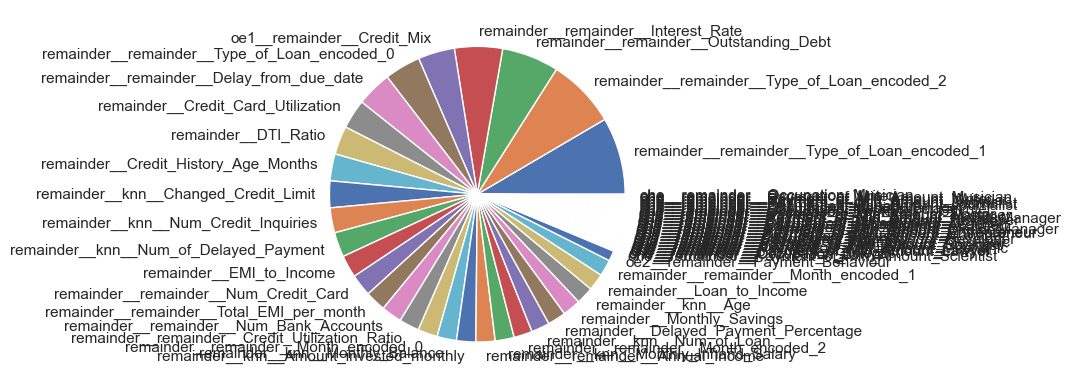

In [282]:
feature_importance.plot(kind='pie')

In [283]:
feature_importance.to_csv('feature_importance.csv')

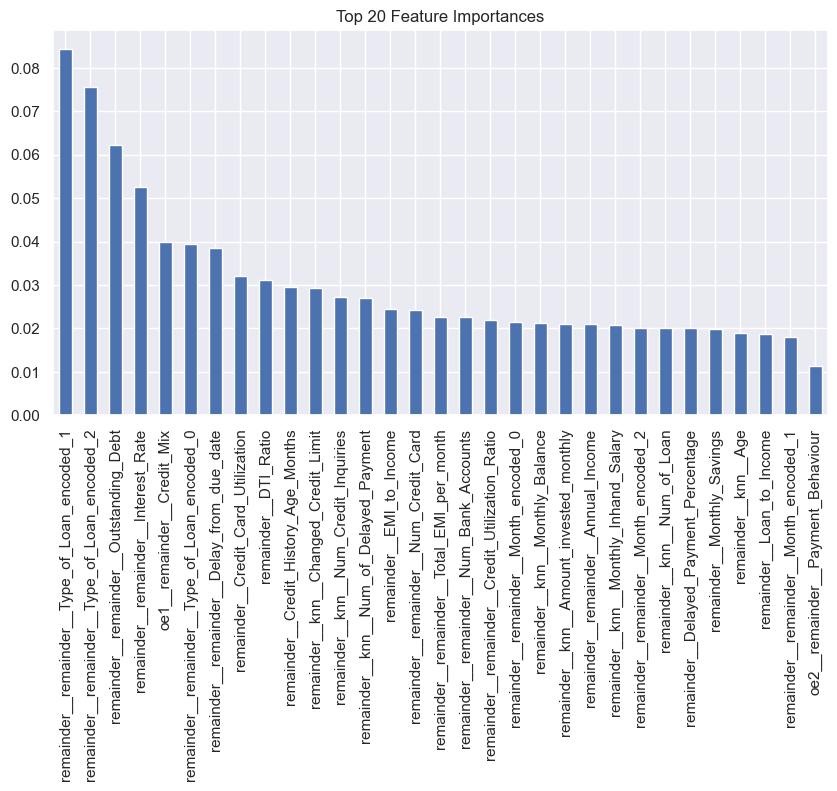

In [284]:
feature_importance.sort_values(ascending=False).head(31).plot(kind='bar', figsize=(10,5))
plt.title("Top 20 Feature Importances")
plt.show()

# Model Building

In [285]:
# Sort features by importance (assuming it's stored in a Pandas Series)
top_features = feature_importance.sort_values(ascending=False).head(31).index

# Select only these features from your dataset
X_selected = train_trf[top_features]

In [286]:
from sklearn.model_selection import train_test_split

In [287]:
x_train,x_test,y_train,y_test = train_test_split(X_selected,y,test_size=0.3,random_state=365)

In [288]:
y_test.shape

(30000,)

In [289]:
from sklearn.preprocessing import MinMaxScaler

In [290]:
scale = MinMaxScaler()

In [291]:
x_train_scaled = scale.fit_transform(x_train)
x_test_scaled = scale.transform(x_test)

In [292]:
# Train the model with selected features
model.fit(x_train_scaled, y_train)

# Evaluate model performance


RandomForestClassifier(random_state=42)

In [293]:
y_pred = model.predict(x_test_scaled)

In [294]:
from sklearn.metrics import accuracy_score

In [295]:
accuracy_score(y_test,y_pred)

0.7994

In [296]:
from sklearn.ensemble import VotingClassifier , BaggingClassifier , StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score ,KFold

## Trying Different Algos

In [297]:
model1 = RandomForestClassifier(n_estimators=100, random_state=42)

# Perform 5-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model1, X_selected, y, cv=kf, scoring='accuracy')

# Print cross-validation results
print("Cross-validation Accuracy scores:", cv_scores)
print(f"Mean Accuracy Score: {cv_scores.mean():.4f}")
print(f"Standard deviation of Accuracy scores: {cv_scores.std():.4f}")

Cross-validation Accuracy scores: [0.7955  0.7993  0.80035 0.7999  0.7991 ]
Mean Accuracy Score: 0.7988
Standard deviation of Accuracy scores: 0.0017


In [298]:
dtc = DecisionTreeClassifier(max_depth=15, min_samples_split=4)
dtc.fit(x_train_scaled,y_train)
y_pred1 = dtc.predict(x_test_scaled)
accuracy_score(y_test,y_pred1)

0.7388333333333333

In [299]:
gbc = GradientBoostingClassifier(n_estimators=100)
gbc.fit(x_train_scaled,y_train)
y_pred2 = gbc.predict(x_test_scaled)
accuracy_score(y_test,y_pred2)

KeyboardInterrupt: 

In [ ]:
estimators=[('rf', model), ('dt', dtc), ('gbc', gbc)]

In [ ]:
vc = VotingClassifier(estimators,voting='soft')

In [ ]:
vc.fit(x_train_scaled,y_train)
y_pred_vc = vc.predict(x_test_scaled)
accuracy_score(y_test,y_pred_vc)

0.7669333333333334

## Deep Learning Model

In [ ]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
x_train_scaled.shape

(70000, 31)

In [ ]:
model = Sequential([
    Dense(512, activation='relu',input_shape=(31,)),

    Dense(512, activation='relu'),


    Dense(256, activation='relu'),



    Dense(256, activation='relu'),



    Dense(128, activation='relu'),



    Dense(64, activation='relu'),



    Dense(64, activation='relu'),



    Dense(32, activation='relu'),


    Dense(3, activation='softmax')
])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 512)                 │          16,384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 512)                 │         262,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 3)                   │              99 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 523,651 (2.00 MB)

 Trainable params: 523,651 (2.00 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [ ]:
model.fit(x_train_scaled,y_train,epochs=25,validation_split=0.2)


Epoch 1/25
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.6980 - loss: 0.6852 - val_accuracy: 0.7041 - val_loss: 0.6526
Epoch 2/25
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.7359 - loss: 0.6027 - val_accuracy: 0.7449 - val_loss: 0.5866
Epoch 3/25
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.7389 - loss: 0.5885 - val_accuracy: 0.7471 - val_loss: 0.5761
Epoch 4/25
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.7409 - loss: 0.5807 - val_accuracy: 0.7403 - val_loss: 0.5819
Epoch 5/25
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.7462 - loss: 0.5764 - val_accuracy: 0.7479 - val_loss: 0.5688
Epoch 6/25
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7463 - loss: 0.5697 - val_accuracy: 0.7509 - val_loss: 0.5692
Epoch 7/25
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.7507 - loss: 0.5629 - val_accuracy: 0.7529 - val_loss: 0.5635
Epoch 8/25
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.7513 - loss: 0

In [ ]:
y_pred_dl = model.predict(x_test_scaled)


938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [ ]:
y_pred_final = y_pred_dl.argmax(axis=1)

In [ ]:
accuracy_score(y_test,y_pred_final)


0.7530333333333333

## HyperParameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
rf = RandomForestClassifier()

In [ ]:
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

# Parameter grid for DecisionTree
param_grid_dtc = {
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Parameter grid for GradientBoosting
param_grid_gbc = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 10],
    'subsample': [0.7, 0.8, 1.0]
}

# Parameter grid for Neural Network
param_grid_nn = {
    'optimizer': ['adam', 'sgd', 'rmsprop'],
    'activation': ['relu', 'tanh'],
    'dropout_rate': [0.2, 0.3, 0.4],
    'epochs': [10, 20],
    'batch_size': [32, 64]
}

In [ ]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV, train_test_split

# Use only 20% of data for hyperparameter tuning
x_train_small, _, y_train_small, _ = train_test_split(x_train_scaled, y_train, test_size=0.8, random_state=42)

# Random Forest (FASTEST OPTIMIZATION)
grid_search_rf = HalvingRandomSearchCV(estimator=rf, param_distributions=param_grid_rf,
                                       factor=3, scoring='accuracy', n_jobs=-1, cv=2)
grid_search_rf.fit(x_train_small, y_train_small)

# Decision Tree (FASTEST OPTIMIZATION)
grid_search_dtc = HalvingRandomSearchCV(estimator=dtc, param_distributions=param_grid_dtc,
                                        factor=3, scoring='accuracy', n_jobs=-1, cv=2)
grid_search_dtc.fit(x_train_small, y_train_small)

# Gradient Boosting (FASTEST OPTIMIZATION)
grid_search_gbc = HalvingRandomSearchCV(estimator=gbc, param_distributions=param_grid_gbc,
                                        factor=3, scoring='accuracy', n_jobs=-1, cv=2)
grid_search_gbc.fit(x_train_small, y_train_small)

# Print best parameters
print("Best Parameters for RandomForest:", grid_search_rf.best_params_)
print("Best Parameters for DecisionTree:", grid_search_dtc.best_params_)
print("Best Parameters for GradientBoosting:", grid_search_gbc.best_params_)


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_search.py:305: UserWarning: The total space of parameters 648 is smaller than n_iter=1166. Running 648 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_search.py:305: UserWarning: The total space of parameters 72 is smaller than n_iter=1166. Running 72 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_search.py:305: UserWarning: The total space of parameters 81 is smaller than n_iter=1166. Running 81 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Parameters for RandomForest: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': True}
Best Parameters for DecisionTree: {'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 20, 'criterion': 'entropy'}
Best Parameters for GradientBoosting: {'subsample': 0.7, 'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.1}


In [ ]:
rf_best = RandomForestClassifier(**grid_search_rf.best_params_, random_state=42)
rf_best.fit(x_train_scaled, y_train)

dtc_best = DecisionTreeClassifier(**grid_search_dtc.best_params_, random_state=42)
dtc_best.fit(x_train_scaled, y_train)

gbc_best = GradientBoostingClassifier(**grid_search_gbc.best_params_, random_state=42)
gbc_best.fit(x_train_scaled, y_train)


GradientBoostingClassifier(max_depth=5, n_estimators=50, random_state=42,
                           subsample=0.7)

In [ ]:
from sklearn.metrics import accuracy_score

y_pred_rf = rf_best.predict(x_test_scaled)
y_pred_dtc = dtc_best.predict(x_test_scaled)
y_pred_gbc = gbc_best.predict(x_test_scaled)

print("RandomForest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("DecisionTree Accuracy:", accuracy_score(y_test, y_pred_dtc))
print("GradientBoosting Accuracy:", accuracy_score(y_test, y_pred_gbc))


RandomForest Accuracy: 0.7976666666666666
DecisionTree Accuracy: 0.7254
GradientBoosting Accuracy: 0.7620333333333333


##  On Test Data

rf_best / dtc_best / gbc_best

In [ ]:
# predict results
results = gbc_best.predict(test_trf[top_features])


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(
